In [ ]:
import torchmetrics

# Tools

- **torchmetrics** — computes task-level metrics (accuracy, F1, etc.) correctly across batches; handles edge cases like class imbalance and accumulation automatically
- **Hooks** — intercept a model's forward or backward pass without modifying it; used to observe activations and gradients at any layer during training
- **TensorBoard** — visualizes what happens *inside a single training run*; loss curves, gradient norms, activation histograms in real time
- **MLflow** — tracks and compares *across multiple runs*; logs hyperparameters, metrics, and model artifacts so you can find the best experiment and store the winning model


# Torchmetrics

Three problems with calculating metrics by hand

1. naive averaging across batches is wrong when batch sizes differ
2. distributed training needs synchronization across processes
3. mixing up train/val/test state (forgetting to reset)

## Core API with 3 functions

Every metric is under torchmetrics.Metric and its subvlass of torch.nn.Module
-> can be moved between devices

1) create metric object instance, seperately for train validation and test
2) update them and inside the loop and compute outside of the loop

update() -> accumulates predictions and

compute() -> reduce to a final value

reset() -> clear state

In [ ]:
import torch
from torchmetrics.regression import MeanAbsoluteError

mae = MeanAbsoluteError()

for features, targets in train_loader:
    preds = net(features)
    mae.update(preds, targets)   # accumulate, no return value

epoch_mae = mae.compute()        # reduce over ALL accumulated batches
mae.reset()                      # clear state before next epoch

# MetricCollection: bundling multiple metrics
for instead of writing .update and compute each time for multiple ones, we can collect them under a metriccolleciton object

```
from torchmetrics import MetricCollection
from torchmetrics.regression import MeanAbsoluteError, MeanSquaredError, R2Score

metrics = MetricCollection({
    "mae": MeanAbsoluteError(),
    "rmse": MeanSquaredError(squared=False),
    "r2": R2Score(),
})

for features, targets in val_loader:
    preds = net(features)
    metrics.update(preds, targets)

results = metrics.compute()   # returns a dict: {"mae": ..., "rmse": ..., "r2": ...}
metrics.reset()
```

##cloning the same set for differentiated train/validation/test metric
the same set for seperating train/valid/test:
`val_metrics = train_metrics.clone()`




# Types of Metrics

# Regression Metrics

| Metric | What it measures                                             | When it's misleading                                                                             |
|---|--------------------------------------------------------------|--------------------------------------------------------------------------------------------------|
| MAE (Mean Absolute Error) | Average absolute error, in original units                    | Weighs large and small errors equally, **"blind" to outliers**                                   |
| MSE (Mean Squared Error) | Average squared error                                        | **Very sensitive to outliers**, hard to interpret (squared units)                                |
| RMSE (Root MSE) | Square root of MSE, back to original units                   | Still inherits MSE's outlier sensitivity                                                         |
| MAPE (Mean Absolute Percentage Error) | Percentage error                                             | Blows up when true value is near 0, asymmetric (penalizes over- vs under-prediction differently) |
| R² (R-squared) | **Fraction of variance explained by the model**              | Can go negative for bad models, artificially inflates with more features (see Adjusted R²)       |
| Pearson/Spearman Correlation | Strength of relationship between predictions and true values | Measures only "direction," not absolute error; can hide systematic bias                          |



## Mean Absolute Error (MAE)

$$MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$$

`from torchmetrics.regression import MeanAbsoluteError`

* Output: Same unit as target (when predicting sales price, output is in dollars)
    * MAE = 1500 means predicitons are of by 1500 USD on average
    * lower is better, 0 is ideal

* Blind to outliers


## Mean Squared Error/ Root of Mean Squared Error

$$MSE = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \qquad RMSE = \sqrt{MSE}$$

```
from torchmetrics.regression import MeanSquaredError

mse = MeanSquaredError()  # squared=True by default
rmse = MeanSquaredError(squared=False) #TO GET ROOT OF IT without taking root
```

* MSE's unit is the target squared (dollars²), so it's hard to interpret on its own; **mostly useful for comparing models to each other or as a loss function** (its gradient penalizes large errors more strongly).
    * - RMSE takes the square root, so it's back in the original unit (dollars) and directly comparable to MAE.

### Commenting RMSE MAE difference:

*- **RMSE is always ≥ MAE.** The gap between them tells you about outliers: RMSE ≈ MAE means errors are fairly homogeneous, RMSE >> MAE means a handful of large errors are dragging the score.


### Mean Absolute Percentage Eror (MAPE)

$$MAPE = \frac{1}{n}\sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$


`from torchmetrics.regression import MeanAbsolutePercentageError`

- MEANING: How much percent did the prediction drifted from the real value?
    - TorchMetrics returns a **fraction**, not a percentage (0.05 means 5%, multiply by 100 to display as a percentage).
    - When comparing targets on **different scales** (like cheap vs expensive houses), unit-freenes help

- Blows up / becomes meaningless if the true value is near zero (unlikely in Ames Housing, but watch for it elsewhere).


# R Squared

$$R^2 = 1 - \frac{\sum_{i}(y_i - \hat{y}_i)^2}{\sum_{i}(y_i - \bar{y})^2}$$

```
from torchmetrics.regression import R2Score
r2 = R2Score()

# p = number of indepented variables / fetautres in model

r2= R2Score(adjusted=p) #for adjusted r2
```


- MEANING: `R²=0.85` means the model explains 85% of the variance in the target; closer to 1 is better.
- Unit-free, typically between 0 and 1 (but can go negative).
- MEANING OF NEGATIVE:  Negative means the model is worse than predicting the mean, a red flag pointing at overfitting, bad feature scaling, or leakage.
- The best regression metric for comparing across different problems since it's scale-independent, but it inflates artificially as you add features, so lean on Adjusted R² for model selection.

# Adjusted R Squared

$R^2_{adj} = 1 - (1-R^2)\cdot\frac{n-1}{n-p-1}$$

where:
- n = number of observations (samples)
- p = number of independent variables (features) in the model
- R² = plain R²

### Why Does R² Inflate as You Add Features?

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$$

SS_tot (the denominator) is fixed, it only depends on the data. But SS_res (residual sum of squares, the numerator) can only decrease or stay the same as you add features, never increase.
This is a direct consequence of how OLS optimizes:
least squares always tries to minimize training error, and every additional feature adds a degree of freedom (a new coefficient = a new way to bend the fit).

**Even a feature with no real relationship to the target can pick up a tiny spurious correlation with noise and nudge SS_res down slightly**



# Pearson and Spearman Correlation

### Pearson Correlation
$$\rho = \frac{\sum_i (y_i - \bar{y})(\hat{y}_i - \bar{\hat{y}})}{\sqrt{\sum_i (y_i - \bar{y})^2}\sqrt{\sum_i (\hat{y}_i - \bar{\hat{y}})^2}}$$

-> normalized covariance:
$\rho = \frac{Cov(X,Y)}{\sigma_X \sigma_Y} ρ=σXσYCov(X,Y) $

```python
from torchmetrics.regression import PearsonCorrCoef, SpearmanCorrCoef

pearson = PearsonCorrCoef()
spearman = SpearmanCorrCoef()
```

- OUTPUT:  Ranges from -1 to 1. Near 1 = strong positive relationship **(predictions rise and fall with true values)**
    -  near 0 = no relationship,
    - near -1 = inverse relationship (a serious red flag in a regression model,e.g. a sign error somewhere in the target)

- Pearson measures linear relationship; Spearman measures rank/monotonic relationship and is more robust to outliers than Pearson.

### Spearman Corrrelation

* Non-parametric counterpart of pearson correlation
* Spearman rorelation doesnt use raw data, **but ranks**

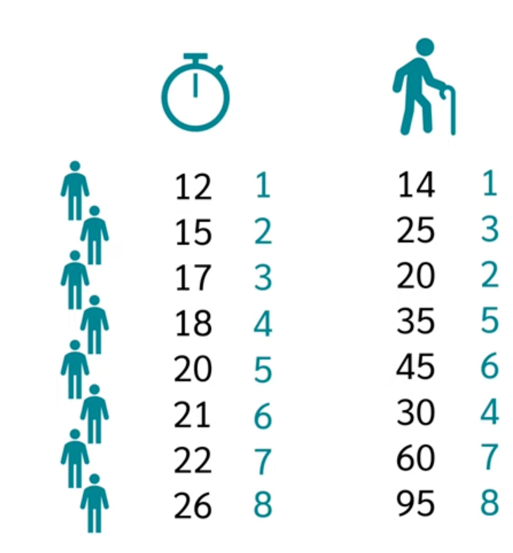

Scatter plot of both:
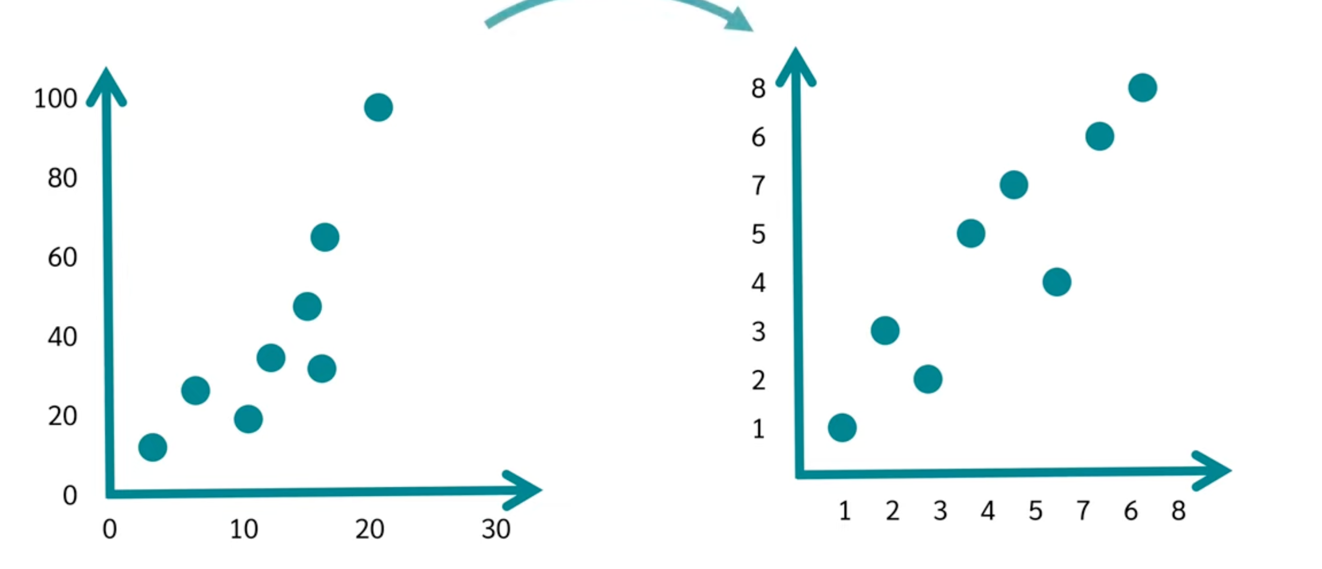

Spearman correlation is then the pearson correlation of the rank

- If one observation has the ame value, average rank (for 2-3 2,5) is assigned


### Why Ranking is used?
- Non linear but monotonic (constantly increasing) relationships can be cathced

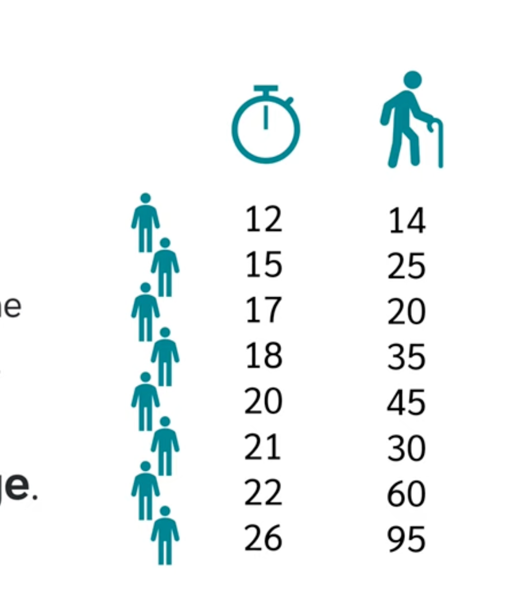

# Accuracy Metrics for Binary Classification

Every metric below is a different combination of four numbers, coming from comparing predicted vs. actual class:

### Confusion Matrix/ Type 1/2 Errors:

|  | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | TP (True Positive) | FN (False Negative) |
| **Actual Negative** | FP (False Positive) | TN (True Negative) |

- **TP** — predicted positive, actually positive. Correct.
- **TN** — predicted negative, actually negative. Correct.
- **FP** (Type I error, "false alarm") — predicted positive, actually negative.
- **FN** (Type II error, "missed case") — predicted negative, actually positive.

### Accuracy
$$Accuracy = \frac{TP+TN}{TP+TN+FP+FN}$$

```python
from torchmetrics.classification import BinaryAccuracy

acc = BinaryAccuracy(threshold=0.5)
acc.update(preds, target)
```

- Fraction between 0 and 1: "what fraction of all predictions were correct."
- **Trap:** meaningless on **imbalanced data**. If 95% of loans don't default, predicting "never defaults" scores 95% accuracy while catching zero actual defaults.
- Only trust this number if your classes are roughly balanced; otherwise look at F1/AUPRC/Balanced Accuracy instead.

#### Threshold:
threshold=0.5 specifies the decision boundary for converting model outputs into binary predictions. Any predicted value greater than or equal to 0.5 is treated as class 1, and any value below 0.5 is treated as class 0.



### Precision
$$Precision = \frac{TP}{TP+FP}$$

```python
from torchmetrics.classification import BinaryPrecision

precision = BinaryPrecision(threshold=0.5)
```


- "Of everything I flagged as **positive** (TP+FP), how much was **actually positive.**"
- Read it as the cost of trusting a positive prediction: `precision=0.80` **means 1 in 5 positive predictions is wrong.**
- High precision = few false alarms. **Matters most when acting on a false positive is expensive** (e.g. flagging a transaction as fraud and blocking a legitimate customer).

### Recall (Sensitivity)
$$Recall = \frac{TP}{TP+FN}$$

```python
from torchmetrics.classification import BinaryRecall

recall = BinaryRecall(threshold=0.5)
```

**Interpreting the output:**
- "Of everything **actually positive**(TP+FN), how much did I catch."
- Read it as how thorough the model is: `recall=0.60` means 40% of real positives are slipping through undetected.
- High recall matters most when missing a positive is expensive (e.g. missing an actual disease case, missing an actual fraud case).

### Precision - Recall Tradeoff:

Precision and recall almost always move in opposite directions as you shift the classification threshold.

- **Lower the threshold** (call more things positive) → recall goes up (you catch more true positives) but precision goes down (you also catch more false positives, since you're being less selective).

 - Plot the full precision-recall curve rather than reading a single threshold's numbers in isolation, this shows you the entire tradeoff surface.
  - Pick the threshold based on the actual cost asymmetry in your problem (cost of a false positive vs. cost of a false negative), not based on which threshold "looks best" on an aggregate metric.
  - If you need one number to summarize the tradeoff across thresholds without picking one, that's exactly what AUROC/AUPRC are for.


- If you've already picked a threshold and precision and recall are both moving together (both up or both down) as you retrain/tune the model, that's a genuine improvement/regression, it's specifically when you change the threshold that they trade off against each other.


### Specificity
$$Specificity = \frac{TN}{TN+FP}$$

```python
from torchmetrics.classification import BinarySpecificity

specificity = BinarySpecificity(threshold=0.5)
```

**Interpreting the output:**
- Recall's mirror image for the negative class: "of everything actually negative, how much did I correctly call negative."
- Rarely reported alone, but matters whenever **false positives on the negative class carry a real cost** (e.g. wrongly flagging a healthy patient as sick).


### F1 / F-beta
$$F_1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall} \qquad F_\beta = (1+\beta^2)\cdot\frac{Precision \cdot Recall}{\beta^2 \cdot Precision + Recall}$$

```python
from torchmetrics.classification import BinaryF1Score, BinaryFBetaScore

f1 = BinaryF1Score()
fbeta = BinaryFBetaScore(beta=2.0)  # beta>1 favors recall
```

**Interpreting the output:**

- Single number between 0 and 1, balancing precision and recall. Only meaningful when you care about both roughly equally, if one matters much more than the other, read that one directly instead of F1.

- Because it's a harmonic mean, F1 **punishes imbalance between precision and recall** harder than a simple average would: **precision=0.9, recall=0.1 gives F1≈0.18, not 0.5.**

#### declaring the important one explicityly with beta:
- F-beta lets **you weight the tradeoff explicitly:** beta=2 (F2) weighs recall twice as important as precision, beta=0.5 (F0.5) weighs precision twice as important as recall.

### AUROC (Area Under the ROC Curve)
$$AUROC = \int_0^1 TPR(FPR^{-1}(x))\, dx$$
(area under the curve of True Positive Rate vs. False Positive Rate across thresholds)

```python
from torchmetrics.classification import BinaryAUROC

auroc = BinaryAUROC()
auroc.update(preds, target)  # preds = probabilities, not hard labels
```

**Interpreting the output:**

- Ranges from 0.5 (random guessing) to 1.0 (perfect ranking).
    - Rough rule of thumb: 0.7-0.8 acceptable, 0.8-0.9 good, 0.9+ strong, but this is domain-dependent, not a universal cutoff.

- Threshold-independent: measures whether the model ranks a random positive above a random negative, across every possible cutoff at once. This is why it doesn't tell you what to set your decision threshold to
    - AUROC answers: If I grab one random actual-positive example and one random actual-negative example, **how often does my model give the positive one a higher score than the negative one?**
  AUROC = **0.85 means: pick a random true positive and a random true negative, 85% of the time the model scores the positive one higher.**

- Can look deceptively good on imbalanced data (it's dominated by how well you separate the classes across all thresholds, not by real-world hit rate at the threshold you'll actually use), which is exactly why AUPRC is often preferred when positives are rare.

### AUPRC (Average Precision)
$$AP = \sum_n (R_n - R_{n-1}) \cdot P_n$$
(weighted sum of precisions at each threshold, weighted by the recall change)

- $R_n$ = the recall obtained after the n-th step (i.e. if you count the top n highest-scored predictions as positive)
- $R_{n-1}$ = the recall at the previous step
- $P_n$ = the precision at the n-th step

```python
from torchmetrics.classification import BinaryAveragePrecision

ap = BinaryAveragePrecision()
```

**Interpreting the output:**
- Ranges 0 to 1.
    - Unlike AUROC, its baseline (random-guess score) **equals the positive class rate (how much of percent/fraction of positive values)**, not a fixed 0.5.
      - so a "good" AUPRC on a dataset with 5% positives looks very different from a good AUPRC on a 50/50 dataset. Always compare against that baseline, not against 0.5.

- More informative than AUROC specifically **when positives are rare**, because it doesn't get inflated by the (usually huge) number of true negatives.

# Accuracy Metrics for Multiclass Classification

Same formulas as binary, computed per class then aggregated.

$$Macro = \frac{1}{C}\sum_{c=1}^{C} Metric_c \qquad Micro = Metric\left(\sum_c TP_c, \sum_c FP_c, \sum_c FN_c\right)$$
$$Weighted = \sum_{c=1}^{C} w_c \cdot Metric_c, \quad w_c = \frac{n_c}{n}$$

```python
from torchmetrics.classification import MulticlassF1Score, MulticlassAccuracy

f1_macro = MulticlassF1Score(num_classes=10, average="macro")
f1_micro = MulticlassF1Score(num_classes=10, average="micro")
f1_weighted = MulticlassF1Score(num_classes=10, average="weighted")

acc_top3 = MulticlassAccuracy(num_classes=10, top_k=3)
